# PointVortex diagnostics and configuration figures

This notebook reads the trajectory and diagnostics CSV files written by any PointVortex backend. It creates publication-style PDF figures of conserved quantities and vortex configurations. Change only the settings in the next cell for a new run.

In [2]:
from pathlib import Path
import csv
import math

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle, Rectangle

# ---- User settings ---------------------------------------------------------
geometry = "periodic"       # "infinite", "periodic", or "disk"
box_length = 1.0             # square side length for periodic geometry
disk_radius = 1.0            # boundary radius for disk geometry
number_of_snapshots = 4      # evenly spaced saved configurations
trajectory_name = "data/vortices.csv"
diagnostics_name = "data/diagnostics.csv"
figure_directory_name = "data/figures"
# ---------------------------------------------------------------------------

if geometry not in {"infinite", "periodic", "disk"}:
    raise ValueError("geometry must be infinite, periodic, or disk")
if number_of_snapshots < 1:
    raise ValueError("number_of_snapshots must be positive")
if not (math.isfinite(box_length) and box_length > 0):
    raise ValueError("box_length must be positive and finite")
if not (math.isfinite(disk_radius) and disk_radius > 0):
    raise ValueError("disk_radius must be positive and finite")

def find_repository_root():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "CMakeLists.txt").is_file() and (candidate / "src").is_dir():
            return candidate
    raise FileNotFoundError("Could not find the PointVortex repository root")

repository_root = find_repository_root()
trajectory_path = repository_root / trajectory_name
diagnostics_path = repository_root / diagnostics_name
figure_directory = repository_root / figure_directory_name
figure_directory.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 10,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "figure.dpi": 120,
    "savefig.bbox": "tight",
})
print(f"Repository: {repository_root}")
print(f"Figures:    {figure_directory}")

Repository: /home/jpl/GitHub/PointVortex
Figures:    /home/jpl/GitHub/PointVortex/data/figures


In [3]:
def read_numeric_csv(path, required_columns):
    if not path.is_file():
        raise FileNotFoundError(f"CSV file not found: {path}")
    with path.open(newline="") as input_file:
        reader = csv.DictReader(input_file)
        fields = set(reader.fieldnames or ())
        missing = set(required_columns) - fields
        if missing:
            raise ValueError(f"{path} is missing columns: {', '.join(sorted(missing))}")
        data = {name: [] for name in reader.fieldnames}
        for row_number, row in enumerate(reader, start=2):
            try:
                values = {name: float(row[name]) for name in reader.fieldnames}
            except (TypeError, ValueError) as error:
                raise ValueError(f"Invalid number in {path} on row {row_number}") from error
            if not all(math.isfinite(value) for value in values.values()):
                raise ValueError(f"Non-finite number in {path} on row {row_number}")
            for name, value in values.items():
                data[name].append(value)
    if not next(iter(data.values()), []):
        raise ValueError(f"CSV file is empty: {path}")
    return {name: np.asarray(values) for name, values in data.items()}

trajectory = read_numeric_csv(
    trajectory_path, {"time", "index", "x", "y", "circulation"}
)
diagnostics = read_numeric_csv(
    diagnostics_path,
    {"time", "circulation", "hamiltonian", "delta_circulation",
     "delta_hamiltonian", "linear_impulse_x", "linear_impulse_y",
     "angular_impulse", "segment_delta_hamiltonian",
     "removed_pairs", "reinjected_pairs"},
)
frame_times = np.unique(trajectory["time"])
if np.any(np.diff(frame_times) <= 0) or np.any(np.diff(diagnostics["time"]) <= 0):
    raise ValueError("Output times must be strictly increasing")
print(f"Loaded {len(frame_times)} trajectory frames and {len(diagnostics['time'])} diagnostics rows")

Loaded 38 trajectory frames and 38 diagnostics rows


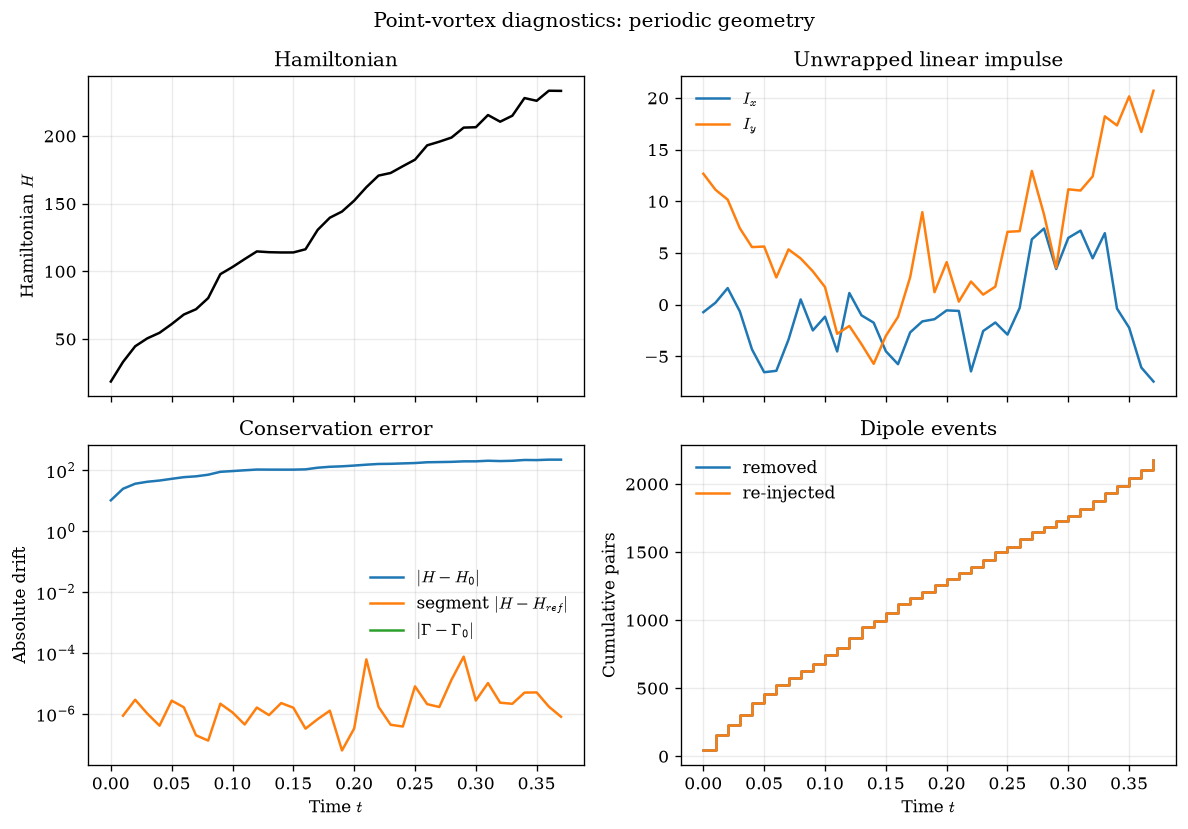

Wrote /home/jpl/GitHub/PointVortex/data/figures/diagnostics_evolution.pdf


In [4]:
# Evolution of diagnostics and geometry-relevant invariants.
time = diagnostics["time"]
fig, axes = plt.subplots(2, 2, figsize=(10.0, 7.0), sharex=True)

axes[0, 0].plot(time, diagnostics["hamiltonian"], color="black")
axes[0, 0].set_ylabel(r"Hamiltonian $H$")
axes[0, 0].set_title("Hamiltonian")

if geometry == "infinite":
    axes[0, 1].plot(time, diagnostics["linear_impulse_x"], label=r"$I_x$")
    axes[0, 1].plot(time, diagnostics["linear_impulse_y"], label=r"$I_y$")
    axes[0, 1].plot(time, diagnostics["angular_impulse"], label=r"$A$")
    axes[0, 1].set_title("Linear and angular impulse")
elif geometry == "periodic":
    axes[0, 1].plot(time, diagnostics["linear_impulse_x"], label=r"$I_x$")
    axes[0, 1].plot(time, diagnostics["linear_impulse_y"], label=r"$I_y$")
    axes[0, 1].set_title("Unwrapped linear impulse")
else:
    axes[0, 1].plot(time, diagnostics["angular_impulse"], label=r"$A$")
    axes[0, 1].set_title("Angular impulse")
axes[0, 1].legend(frameon=False)

def nonzero_absolute(values):
    absolute = np.abs(values)
    return np.where(absolute > 0, absolute, np.nan)

axes[1, 0].semilogy(time, nonzero_absolute(diagnostics["delta_hamiltonian"]),
                     label=r"$|H-H_0|$")
axes[1, 0].semilogy(time, nonzero_absolute(diagnostics["segment_delta_hamiltonian"]),
                     label=r"segment $|H-H_{ref}|$")
axes[1, 0].semilogy(time, nonzero_absolute(diagnostics["delta_circulation"]),
                     label=r"$|\Gamma-\Gamma_0|$")
axes[1, 0].set(xlabel=r"Time $t$", ylabel="Absolute drift", title="Conservation error")
axes[1, 0].legend(frameon=False)

axes[1, 1].step(time, diagnostics["removed_pairs"], where="post", label="removed")
axes[1, 1].step(time, diagnostics["reinjected_pairs"], where="post", label="re-injected")
axes[1, 1].set(xlabel=r"Time $t$", ylabel="Cumulative pairs", title="Dipole events")
axes[1, 1].legend(frameon=False)

fig.suptitle(f"Point-vortex diagnostics: {geometry} geometry")
fig.tight_layout()
diagnostics_pdf = figure_directory / "diagnostics_evolution.pdf"
fig.savefig(diagnostics_pdf)
plt.show()
print(f"Wrote {diagnostics_pdf}")

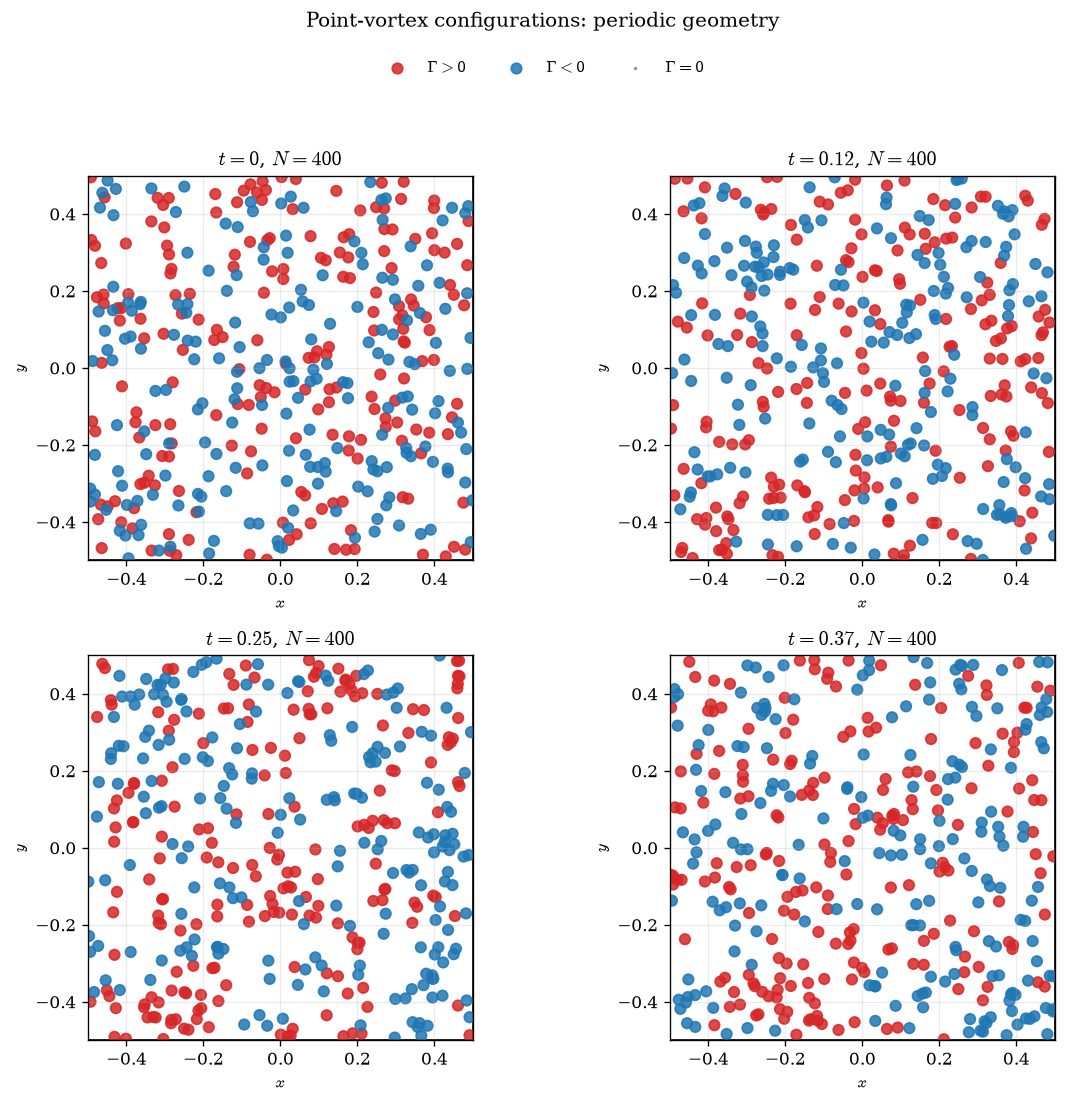

Wrote /home/jpl/GitHub/PointVortex/data/figures/vortex_configurations.pdf


In [5]:
# Physical-space configurations at evenly spaced saved times.
snapshot_count = min(number_of_snapshots, len(frame_times))
snapshot_indices = np.unique(np.rint(np.linspace(0, len(frame_times) - 1, snapshot_count)).astype(int))
snapshot_times = frame_times[snapshot_indices]
columns = min(2, len(snapshot_times))
rows = int(math.ceil(len(snapshot_times) / columns))
fig, axes = plt.subplots(rows, columns, figsize=(5.0 * columns, 4.6 * rows), squeeze=False)

if geometry == "infinite":
    visible = trajectory["circulation"] != 0
    all_x, all_y = trajectory["x"][visible], trajectory["y"][visible]
    span = max(np.ptp(all_x), np.ptp(all_y), 1.0e-12)
    x_limits = (float(np.min(all_x) - 0.05 * span), float(np.max(all_x) + 0.05 * span))
    y_limits = (float(np.min(all_y) - 0.05 * span), float(np.max(all_y) + 0.05 * span))
elif geometry == "periodic":
    x_limits = y_limits = (-0.5 * box_length, 0.5 * box_length)
else:
    x_limits = y_limits = (-disk_radius, disk_radius)

for axis, selected_time in zip(axes.flat, snapshot_times):
    mask = trajectory["time"] == selected_time
    x = trajectory["x"][mask].copy()
    y = trajectory["y"][mask].copy()
    gamma = trajectory["circulation"][mask]
    if geometry == "periodic":
        x = (x + 0.5 * box_length) % box_length - 0.5 * box_length
        y = (y + 0.5 * box_length) % box_length - 0.5 * box_length
        axis.add_patch(Rectangle((-0.5 * box_length, -0.5 * box_length), box_length, box_length,
                                 fill=False, color="black", linewidth=1.0))
    elif geometry == "disk":
        axis.add_patch(Circle((0, 0), disk_radius, fill=False, color="black", linewidth=1.2))
    marker_area = 18.0 + 22.0 * np.abs(gamma) / max(float(np.max(np.abs(gamma))), 1.0e-15)
    axis.scatter(x[gamma > 0], y[gamma > 0], s=marker_area[gamma > 0], color="tab:red",
                 label=r"$\Gamma>0$", alpha=0.85)
    axis.scatter(x[gamma < 0], y[gamma < 0], s=marker_area[gamma < 0], color="tab:blue",
                 label=r"$\Gamma<0$", alpha=0.85)
    axis.scatter(x[gamma == 0], y[gamma == 0], s=marker_area[gamma == 0], color="0.5",
                 label=r"$\Gamma=0$", alpha=0.85)
    axis.set(xlim=x_limits, ylim=y_limits, xlabel=r"$x$", ylabel=r"$y$",
             title=rf"$t={selected_time:.6g}$, $N={len(x)}$")
    axis.set_aspect("equal", adjustable="box")

for axis in axes.flat[len(snapshot_times):]:
    axis.set_visible(False)
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.965),
           ncol=max(1, len(labels)), frameon=False)
fig.suptitle(f"Point-vortex configurations: {geometry} geometry", y=0.995)
fig.tight_layout(rect=(0, 0, 1, 0.92))
configurations_pdf = figure_directory / "vortex_configurations.pdf"
fig.savefig(configurations_pdf)
plt.show()
print(f"Wrote {configurations_pdf}")

The PDFs are written to `data/figures/` by default. For periodic geometry, unwrapped solver coordinates are wrapped into the fundamental square for display only. Infinite-plane limits cover the full selected trajectory, while disk figures draw the circular boundary.